In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

plt.style.use('default')

In [3]:
stocks = ['RELIANCE.NS', 'TCS.NS', 'INFY.NS']

data = yf.download(stocks, start="2020-01-01", end="2024-01-01")['Close']
data.head()

[*********************100%***********************]  3 of 3 completed


Ticker,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,
2020-01-01,633.151001,675.324158,1866.113647
2020-01-02,631.303650,686.821228,1857.547729
2020-01-03,641.013428,687.648804,1894.566650
2020-01-06,634.869568,671.700623,1894.394775
2020-01-07,625.460693,682.034546,1899.043701


In [4]:
print(data.isnull().sum())
data = data.dropna()

Ticker
INFY.NS        0
RELIANCE.NS    0
TCS.NS         0
dtype: int64


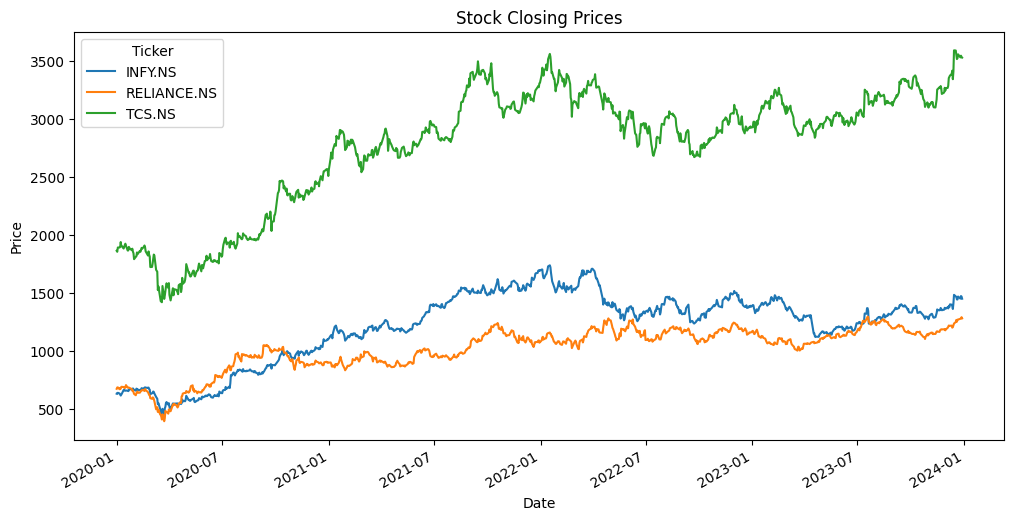

In [5]:
data.plot(figsize=(12,6))
plt.title("Stock Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [6]:
returns = data.pct_change()
returns.head()

Ticker,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,
2020-01-01,NaN,NaN,NaN
2020-01-02,-0.002918,0.017025,-0.004590
2020-01-03,0.015381,0.001205,0.019929
2020-01-06,-0.009585,-0.023192,-0.000091
2020-01-07,-0.014820,0.015385,0.002454


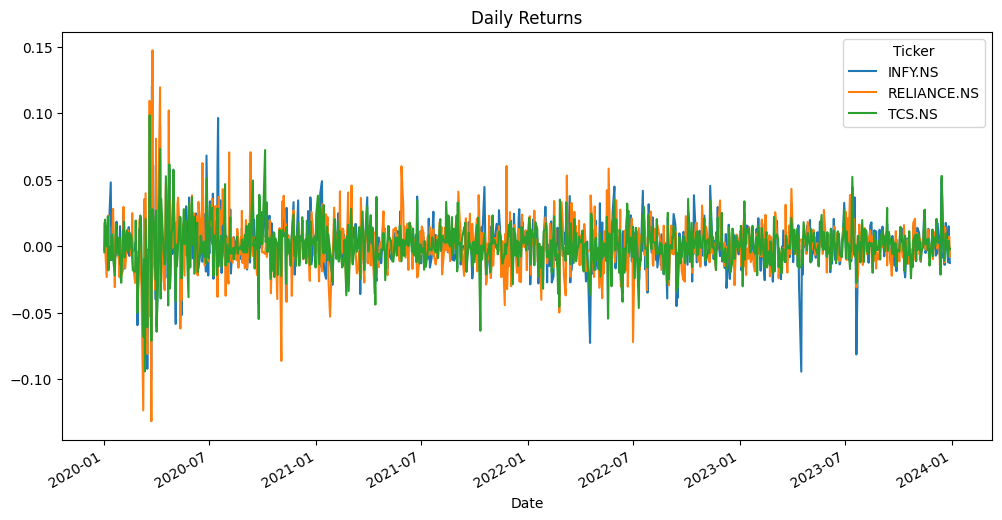

In [7]:
returns.plot(figsize=(12,6))
plt.title("Daily Returns")
plt.show()


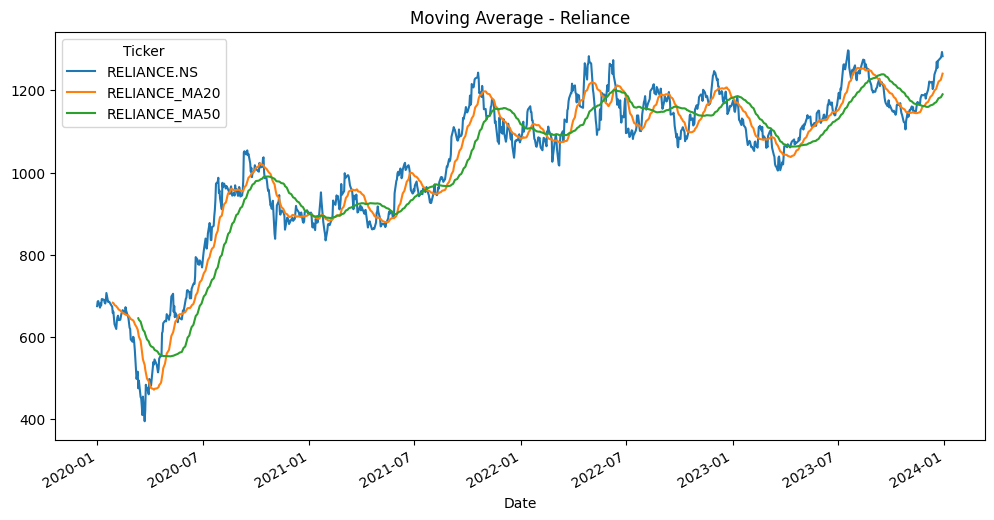

In [8]:
ma_data = data.copy()

ma_data['RELIANCE_MA20'] = data['RELIANCE.NS'].rolling(20).mean()
ma_data['RELIANCE_MA50'] = data['RELIANCE.NS'].rolling(50).mean()

ma_data[['RELIANCE.NS', 'RELIANCE_MA20', 'RELIANCE_MA50']].plot(figsize=(12,6))
plt.title("Moving Average - Reliance")
plt.show()

In [9]:
volatility = returns.std()
print("Volatility:\n", volatility)


Volatility:
 Ticker
INFY.NS        0.018249
RELIANCE.NS    0.019653
TCS.NS         0.015897
dtype: float64


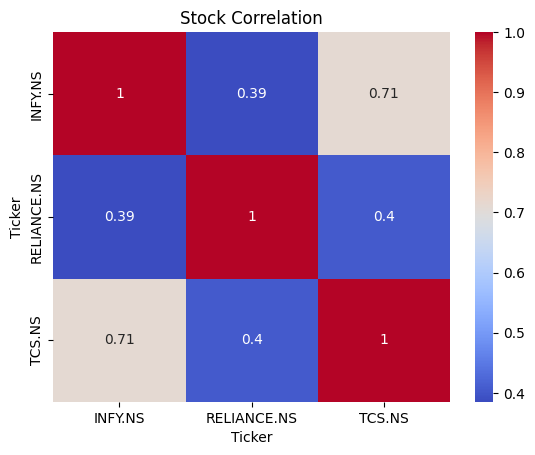

In [10]:
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm')
plt.title("Stock Correlation")
plt.show()